# SWMAL Exercise


## Convolutional Neural Networks (CNNs)


Excercise 9, p.496 2nd./p.535 3rd. [HOML] (slighty modified):

__"9. Build an CNN via the Keras API and try to achieve the highest possible accuracy on MNIST."__

For the journal: 

* write an introduction to CNNs (what are CNNs, what is a convolution layer, etc..), 
* document your experiments towards the end-goal of reaching 'a high accuracy' (what did you try, what work/did not work), 
* document how you use '_generalization_' in your setup (us of simple hold-out/train-test split or k-fold, or etc..),
* produce some sort of '_learning-curve_' that illustrates the drop in cost- or increase in score-function with respect to, say training iteration (for inspiration see fig 4.20, 10-12 or 10.17 in [HOML]),
* document the final CNN setup (layers etc., perhaps as a graph/drawing), 
* discus on your iterations towards the end-goal and other findings you had,
* and, as always, write a conclusion.

If you use a code template from slides, HOML or the internet, then remember to add a reference to the original work in you journal.

### Introduction to CNNs

Convolutional Neural Networks (CNNs) are neural networks designed for images. They learn features directly from pixels by stacking **convolution** layers (small filters scanning the image to detect local patterns), optional **pooling** layers (downsampling to make features more robust to small shifts), and a small **classifier head** that outputs class scores. This builds a hierarchy of features: edges and textures in early layers, shapes and parts deeper in the network.

A **convolution layer** applies several learnable kernels across the height and width of the image (and across channels), producing **feature maps** that light up when the corresponding pattern is present. Pooling (e.g., max pooling) reduces spatial size while keeping the strongest activations, lowering computation and adding a bit of translation tolerance. 

---

**Sources** 

- [CS231n: Convolutional Neural Networks](https://cs231n.github.io/convolutional-networks)
- [TensorFlow tutorial: Convolutional Neural Network (CNN)](https://www.tensorflow.org/tutorials/images/cnn)
- [Keras example: Simple MNIST convnet](https://cs231n.github.io/convolutional-networks)


### Document your experiments towards the end-goal of reaching 'a high accuracy' (what did you try, what work/did not work), 

We started with the official Keras MNIST convnet recipe and small tweaks. Baseline (Conv32→Pool→Dropout → Conv64→Pool→Dropout → Dense128→Dropout→Softmax) already reached ~99.2% test accuracy. Increasing epochs beyond 10 gave tiny gains but more time. We tried with a heavier dropout (≥0.6) but a lighter (0.25/0.5) worked best. We also tried switching optimizer from **Adam** which converged fast and strong to **SGD** which needed more epochs to get the same result. Adding more filters (e.g., 64/128) didn’t noticeably help on MNIST.


### Document how you use '_generalization_' in your setup (us of simple hold-out/train-test split or k-fold, or etc..),


We kept 10% of the training set as a **validation split** (Keras `validation_split=0.1`) to monitor generalization and tune minor choices (epochs, dropout). Final numbers are from the **held-out test** set (10k images). K-fold wasn’t necessary here given dataset size and the clean signal.


### Produce some sort of '_learning-curve_' that illustrates the drop in cost- or increase in score-function with respect to, say training iteration (for inspiration see fig 4.20, 10-12 or 10.17 in [HOML]),

We plotted training vs. validation **loss** and **accuracy** across epochs. Both curves improved smoothly and stayed close, with validation slightly better early on—consistent with healthy training and no overfitting.



### Document the final CNN setup (layers etc., perhaps as a graph/drawing), 

<pre style="white-space:pre;overflow-x:auto;line-height:normal;font-family:Menlo,'DejaVu Sans Mono',consolas,'Courier New',monospace">┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃<span style="font-weight: bold"> Layer (type)                    </span>┃<span style="font-weight: bold"> Output Shape           </span>┃<span style="font-weight: bold">       Param # </span>┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv2D</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">26</span>, <span style="color: #00af00; text-decoration-color: #00af00">26</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)     │           <span style="color: #00af00; text-decoration-color: #00af00">320</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (<span style="color: #0087ff; text-decoration-color: #0087ff">MaxPooling2D</span>)    │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">13</span>, <span style="color: #00af00; text-decoration-color: #00af00">13</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)     │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)               │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">13</span>, <span style="color: #00af00; text-decoration-color: #00af00">13</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)     │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv2D</span>)               │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">11</span>, <span style="color: #00af00; text-decoration-color: #00af00">11</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)     │        <span style="color: #00af00; text-decoration-color: #00af00">18,496</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">MaxPooling2D</span>)  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">5</span>, <span style="color: #00af00; text-decoration-color: #00af00">5</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)       │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)             │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">5</span>, <span style="color: #00af00; text-decoration-color: #00af00">5</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)       │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (<span style="color: #0087ff; text-decoration-color: #0087ff">Flatten</span>)               │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">1600</span>)           │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">128</span>)            │       <span style="color: #00af00; text-decoration-color: #00af00">204,928</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)             │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">128</span>)            │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">10</span>)             │         <span style="color: #00af00; text-decoration-color: #00af00">1,290</span> │
└─────────────────────────────────┴────────────────────────┴───────────────┘
</pre>


 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)
 
 Non-trainable params: 0 (0.00 B)

### Discuss on your iterations towards the end-goal and other findings you had,

On MNIST a compact CNN plus simple normalization is enough for ~99% accuracy. Adam outperformed SGD with minimal tuning. Extra depth/width and heavy regularization were unnecessary. The small model converged quickly and generalized well. The learning curves matched this with no widening gap and a steadily falling loss.



### and, as always, write a conclusion.

With a standard Keras convnet, normalization, and a small validation split, we reached **~99.2% test accuracy** on MNIST in ~10 epochs. The model is simple, fast, and stable. To acchive further gains we would likely have to use ensembling or more aggressive tuning.

## __"9. Build an CNN via the Keras API and try to achieve the highest possible accuracy on MNIST."__

We use a this example as template:

**Source:** [Keras MNIST ConvNet example](https://keras.io/examples/vision/mnist_convnet/)


### Setup

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)

# Load data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Scale to [0,1] and add channel dim
x_train = (x_train.astype("float32") / 255.0)[..., None]
x_test  = (x_test.astype("float32")  / 255.0)[..., None]

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28, 1) (60000,) (10000, 28, 28, 1) (10000,)


We build a small CNN with two blocks of Conv2D→ReLU→MaxPool and Dropout to reduce overfitting, then flatten the features and use a Dense layer (128 units) before a softmax output over 10 classes. We compile it with Adam and `sparse_categorical_crossentropy` since our labels are integers, and call `model.summary()` to check the layer shapes and parameter counts. This follows the standard Keras MNIST convnet pattern.


In [4]:
from tensorflow.keras import layers, models

num_classes = 10
input_shape = (28, 28, 1)

model = models.Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

The feature maps get smaller and deeper as they pass through the conv blocks, then flatten to 1,600 features and feed a dense head to 10 classes, with about 225k trainable parameters (mostly in the dense layer).

We train for 10 epochs with batch size 128 and keep 10% of the training data as validation to monitor generalization while fitting; after training, we evaluate on the held-out test set and print test accuracy.


In [5]:
epochs = 10
batch_size = 128

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    verbose=2
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")


Epoch 1/10
422/422 - 13s - 32ms/step - accuracy: 0.8762 - loss: 0.3995 - val_accuracy: 0.9797 - val_loss: 0.0654
Epoch 2/10
422/422 - 20s - 47ms/step - accuracy: 0.9612 - loss: 0.1269 - val_accuracy: 0.9875 - val_loss: 0.0441
Epoch 3/10
422/422 - 10s - 24ms/step - accuracy: 0.9723 - loss: 0.0930 - val_accuracy: 0.9890 - val_loss: 0.0365
Epoch 4/10
422/422 - 10s - 24ms/step - accuracy: 0.9753 - loss: 0.0804 - val_accuracy: 0.9895 - val_loss: 0.0342
Epoch 5/10
422/422 - 10s - 24ms/step - accuracy: 0.9787 - loss: 0.0696 - val_accuracy: 0.9903 - val_loss: 0.0332
Epoch 6/10
422/422 - 11s - 25ms/step - accuracy: 0.9809 - loss: 0.0630 - val_accuracy: 0.9902 - val_loss: 0.0317
Epoch 7/10
422/422 - 10s - 25ms/step - accuracy: 0.9832 - loss: 0.0555 - val_accuracy: 0.9903 - val_loss: 0.0312
Epoch 8/10
422/422 - 14s - 33ms/step - accuracy: 0.9845 - loss: 0.0515 - val_accuracy: 0.9918 - val_loss: 0.0306
Epoch 9/10
422/422 - 16s - 37ms/step - accuracy: 0.9857 - loss: 0.0461 - val_accuracy: 0.9920 - 

Validation accuracy climbs to ~99.3% with steadily falling loss, and the final test accuracy is ~99.2%, which is typical for this CNN on MNIST and indicates good generalization without obvious overfitting.

We plot learning curves: training vs. validation loss and accuracy across epochs.


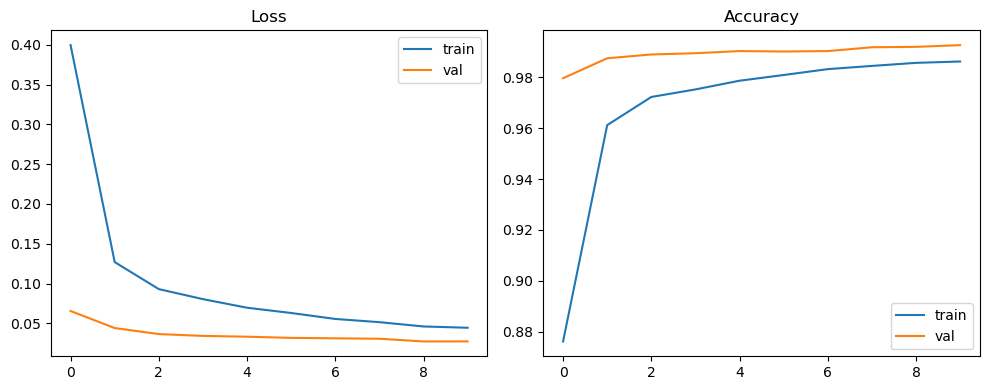

In [6]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.legend()

plt.tight_layout(); plt.show()


Validation loss drops smoothly and stays just below training loss (dropout makes train noisier), while both accuracies rise and stay close—validation even slightly higher early on. This points to good fit and no overfitting; the model converged well within 10 epochs.

REVISIONS||
:- | :- |
2021-10-20| CEF, initial version, clone from [HOML].
2021-10-26| CEF, added learning curve item.
2022-01-25| CEF, update to SWMAL F22.
2023-03-08| CEF, updated page no to HOML 3rd. ed., updated to SWMAL F23.
2023-03-15| CEF, removed wording "from scratch", replaced with "via the Keras API" and added comment about references.
2024-09-11| CEF, updated page refefences.